# ΔM (Delta Modulation) デモノート

このノートブックでは、librosa を用いてサンプル音声を読み込み・可視化しながら ΔM（デルタ変調）のステップや波形の特徴を確認できるようになっています。
音声のロードやスペクトル表示、差分信号の生成といった処理の多くは [librosa](https://librosa.org/doc) の API に依存しているため、ノートを実行する際は librosa と matplotlib、IPython などの依存ライブラリをインストールしておいてください。

In [6]:
import IPython
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

#### グラフと音声: オリジナル信号の確認
librosa で読み込んだ音声の時間波形と実際の音声をここで可視化・再生し、以降の処理と比較できる基準を用意します。


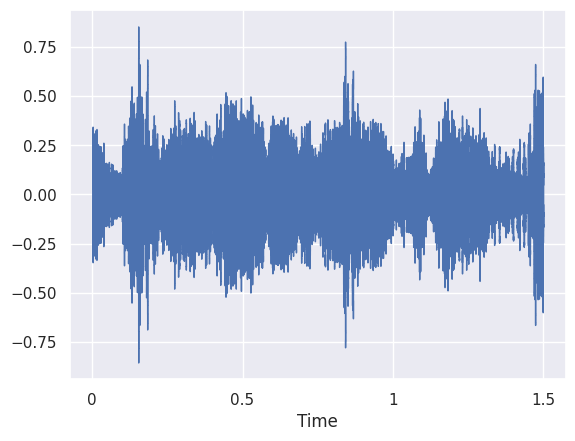

In [7]:
y, sr = librosa.load(librosa.ex('fishin'), offset=15, duration=1.5)
librosa.display.waveshow(y, sr=sr)
plt.show()
IPython.display.Audio(y, rate=sr)

#### グラフ: ΔM 変調とスペクトルの内訳
次のセルでは ΔM で量子化した波形 `z` とビット列 `b` を生成し、時間領域およびスペクトログラムの両面から挙動を観察します。


#### パラメーター: `delta_y` と `skip_t` の役割
- `delta_y`: ΔM で振幅を上下させる最小ステップ。値が小さいほど元波形に細かく追従できますが、ビット列の変動が増えやすくなります。
- `skip_t`: サンプルを何点おきに判定してデルタ更新するかを決める間引き間隔。値が大きいと計算は軽くなりますが、高速変化の成分で歪みが増えます。
これらを調整することで、ΔM の追従精度とビット列の安定性のトレードオフを制御できます。


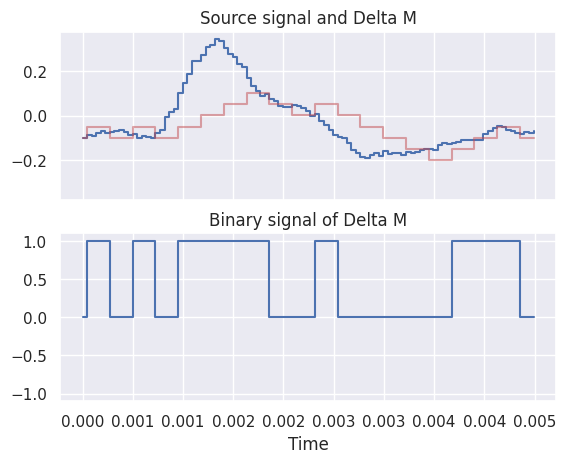

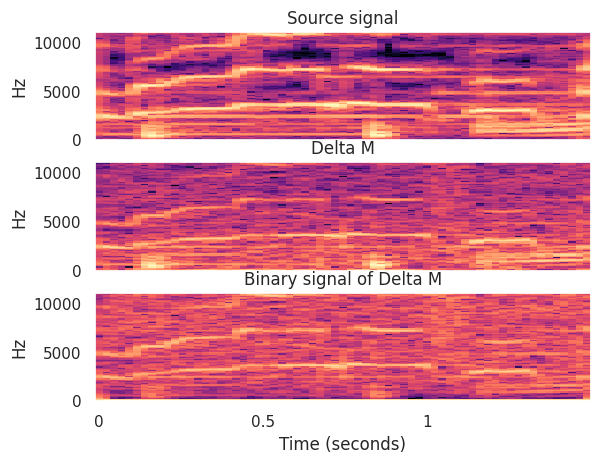

In [8]:
from scipy.special import y1_zeros
delta_y = 0.05
skip_t = 5
delta_t = skip_t/sr

# yが元信号波形
# bがデルタ変調波形
# zはデルタ変調から再生された波形
z = np.zeros(len(y))
b = np.zeros(len(y))
z[0] = y[0]
b[0] = 0
for i in range(1, len(y)-1, skip_t):
  #print("i:{}".format(i))
  diff = y[i] - z[i-1]
  if diff < 0:
    z[i] = z[i-1] - delta_y
    b[i] = 0
  else:
    z[i] = z[i-1] + delta_y
    b[i] = 1
  for j in range(i+1,min(i+skip_t, len(y)-1)):
    #print("j:{}".format(j))
    z[j] = z[i]
    b[j] = b[i]

fig, ax = plt.subplots(nrows=2, sharex=True)
librosa.display.waveshow(y[:100], sr=sr, ax=ax[0], label='Source signal')
librosa.display.waveshow(z[:100], sr=sr, color='r', alpha=0.5, ax=ax[0], label='Delta M')
ax[0].set(title='Source signal and Delta M')
ax[0].label_outer()

librosa.display.waveshow(b[:100], sr=sr, color='b', ax=ax[1])
ax[1].set(title='Binary signal of Delta M')
ax[1].label_outer()

fig, ax = plt.subplots(nrows=3, sharex=True)
Y = librosa.stft(y)
Ydb = librosa.amplitude_to_db(np.abs(Y), ref=np.max)
imgY = librosa.display.specshow(Ydb[:100], y_axis='linear', x_axis='s', sr=sr, ax=ax[0])
ax[0].set(title='Source signal')
ax[0].label_outer()

Z = librosa.stft(z)
Zdb = librosa.amplitude_to_db(np.abs(Z), ref=np.max)
imgZ = librosa.display.specshow(Zdb[:100], y_axis='linear', x_axis='s', sr=sr, ax=ax[1])
ax[1].set(title='Delta M')
ax[1].label_outer()

B = librosa.stft(b)
Bdb = librosa.amplitude_to_db(np.abs(B), ref=np.max)
imgB = librosa.display.specshow(Bdb[:100], y_axis='linear', x_axis='s', sr=sr, ax=ax[2])
ax[2].set(title='Binary signal of Delta M')
ax[2].label_outer()

#### 音声: ΔM 復号波形
ΔM によって段階量子化された波形 `z` を再生し、元信号との聴感上の違いを確認します。


In [9]:
IPython.display.Audio(z, rate=sr)

#### 音声: ΔM ビット列の再生
ビット列 `b` を 0/1 のステップ波として音に変換し、デルタ変調で送信されるデジタル信号の様子を耳で把握します。


In [10]:
IPython.display.Audio(b, rate=sr)